In [7]:
# 1. IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)


In [23]:
# 2. LOAD DATA
import pandas as pd

X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").values.ravel()

#
X_test_lgb = X_test.copy()
X_test_cat = X_test.copy()

#
X_test_lgb = X_test_lgb.astype(float)

y_pred_lgb_proba = lgb_model.predict_proba(X_test_lgb)[:, 1]

#
cat_features = ["Cluster"]

# restore categorical
for col in cat_features:
    X_test_cat[col] = X_test_cat[col].astype(int)

# convert to category
for col in cat_features:
    X_test_cat[col] = X_test_cat[col].astype("category")

y_pred_cat_proba = cat_model.predict_proba(X_test_cat)[:, 1]

In [25]:
# 3. LOAD TRAINED MODELS
import joblib

lgb_model = joblib.load("checkpoints/lightgbm_model.pkl")
cat_model = joblib.load("checkpoints/catboost_model.pkl")

In [26]:
# 4. PREDICT PROBABILITY
# predict probability for positive class (churn = 1)

y_pred_lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
y_pred_cat_proba = cat_model.predict_proba(X_test)[:, 1]

In [27]:
# 5. CONVERT TO CLASS (THRESHOLD = 0.5)
# convert probability to class label

y_pred_lgb = (y_pred_lgb_proba >= 0.5).astype(int)
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)

In [28]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_lgb_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()

best_threshold = thresholds[best_idx]

print("Best threshold (LGBM):", best_threshold)

Best threshold (LGBM): 0.9999987098531626


In [29]:
y_pred_lgb = (y_pred_lgb_proba >= best_threshold).astype(int)

In [31]:
# 6. CALCULATE METRICS
# ROC-AUC
roc_lgb = roc_auc_score(y_test, y_pred_lgb_proba)
roc_cat = roc_auc_score(y_test, y_pred_cat_proba)

# F1-score
f1_lgb = f1_score(y_test, y_pred_lgb)
f1_cat = f1_score(y_test, y_pred_cat)

# PR-AUC (important for imbalance)
pr_lgb = average_precision_score(y_test, y_pred_lgb_proba)
pr_cat = average_precision_score(y_test, y_pred_cat_proba)

# print results
print("=== MODEL COMPARISON ===")
print(f"LightGBM - ROC AUC: {roc_lgb:.4f}, F1: {f1_lgb:.4f}, PR AUC: {pr_lgb:.4f}")
print(f"CatBoost - ROC AUC: {roc_cat:.4f}, F1: {f1_cat:.4f}, PR AUC: {pr_cat:.4f}")

=== MODEL COMPARISON ===
LightGBM - ROC AUC: 1.0000, F1: 1.0000, PR AUC: 1.0000
CatBoost - ROC AUC: 1.0000, F1: 1.0000, PR AUC: 1.0000


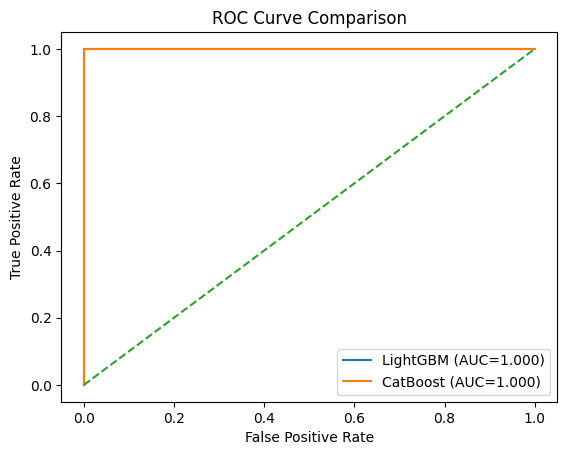

In [32]:
# 7. ROC CURVE
# ==============================

# compute ROC curve
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_lgb_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_pred_cat_proba)

plt.figure()

# plot both models
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={roc_lgb:.3f})")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC={roc_cat:.3f})")

# random baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

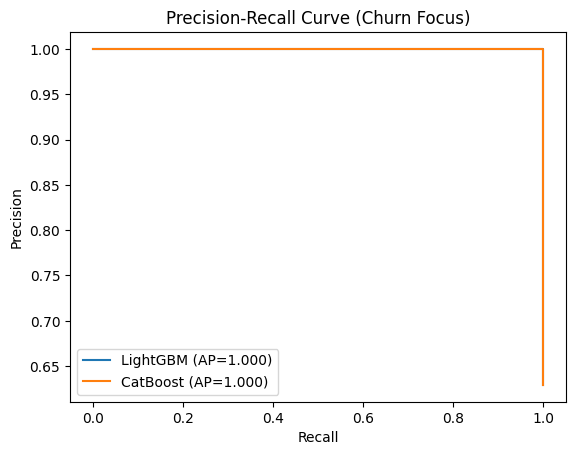

In [33]:
# 8. PRECISION-RECALL CURVE (IMPORTANT)
# ==============================

precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_pred_lgb_proba)
precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_pred_cat_proba)

plt.figure()

# plot PR curve
plt.plot(recall_lgb, precision_lgb, label=f"LightGBM (AP={pr_lgb:.3f})")
plt.plot(recall_cat, precision_cat, label=f"CatBoost (AP={pr_cat:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Churn Focus)")
plt.legend()

In [34]:
# 9. SAVE FIGURE
plt.figure()
# ROC
plt.savefig("roc_curve.png")

plt.figure()
# PR
plt.savefig("pr_curve.png")

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>